In [1]:
# Cargar la extensión mágica de SQL
%load_ext sql

In [2]:
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/13_intro_sql.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/13_intro_sql.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

In [3]:
import qrcode
from IPython.display import display
from PIL import Image

def generar_qr(url, version=1, box_size=5, border=4, fill_color="black", back_color="white"):
    qr = qrcode.QRCode(
        version=version,
        error_correction=qrcode.constants.ERROR_CORRECT_L,
        box_size=box_size,
        border=border,
    )
    
    # Añadir la URL al QR
    qr.add_data(url)
    qr.make(fit=True)
    
    # Crear la imagen del QR
    img = qr.make_image(fill_color=fill_color, back_color=back_color)
     
    return img



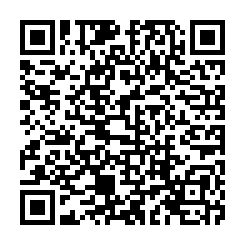

In [4]:
url = "https://colab.research.google.com/github/marco-canas/fundamentos_de_programacion/blob/main/2_clases/unidad4/13_intro_sql.ipynb"
generar_qr(url) 

### [Video de apoyo a la lectura interactiva y experimental de este cuaderno]()

### [Vínculo al programa del curso de Fundamentos de Programación:](https://github.com/marco-canas/fundamentos_de_programacion/blob/main/programa/Programa_Fundamentos_Programacion.md)



## Código del curso: 314029

Un reconocimiento a mis estudiantes que han construido conmigo este saber pedagógico:

<img src = 'https://github.com/marco-canas/algebra_y_trigonometria/blob/main/7_images/5_clase_3_2025-08-12_hora_11_04.jpg?raw=true' width = 400> 



A continuación, se presenta la propuesta para rediseñar la clase del Capítulo 12, integrando el lenguaje **SQL** junto con Python, Pandas, NumPy y Matplotlib para la gestión del flujo de datos. 

Además, se detalla la reestructuración del dataset de ejemplo adaptado a la subregión socioeconómica de **Caucasia, Antioquia**, transformándolo desde una estructura plana de DataFrame de Pandas a un modelo relacional de archivos de datos estructurados para su administración con SQL.

---



# La Clase: CAPÍTULO 13: Análisis de Datos y Gestión Relacional con SQL



## Objetivos de la Clase Renovada



* Aplicar de forma integrada conocimientos de **SQL** para la extracción, filtrado y preparación de datos alojados en bases de datos relacionales.


* Conectar **Python (Pandas/SQLAlchemy o SQLite3)** con motores de bases de datos para integrar el análisis relacional con capacidades analíticas de **Pandas, NumPy y Matplotlib**.


* Seguir el flujo de trabajo real de un Científico y Administrador de Datos ante un problema de negocio regional mediante técnicas de limpieza híbridas (SQL para tipos/restricciones y Python para imputación avanzada).



## Estructura del Flujo de Trabajo en Clase



### 1. Definición del Problema Empresarial y del Modelo de Datos

* **Contexto de Negocio en Caucasia:** Retención de microempresarios y clientes comerciales frente a condiciones de ingresos informales y acceso a créditos en el Bajo Cauca.
* **Meta del Análisis:** Identificar segmentos de clientes insatisfechos cruzando transacciones físicas, perfiles crediticios y sectores económicos (Ganadería, Minería, Comercio Minorista, Independientes).
* **Enfoque SQL:** En lugar de operar sobre un único archivo plano `.csv` cargado en memoria, los estudiantes modelarán y consultarán tablas relacionales que separan la información demográfica, financiera y operativa del cliente.



### 2. Arquitectura de Datos: De DataFrame Único a Tablas SQL

El almacenamiento monolítico anterior se divide en un esquema relacional de tres tablas para optimizar la integridad y simular un entorno corporativo real:

```
[Tabla: clientes] (1) <------- (M) [Tabla: ingresos_credito]
                          |
                          |--- (M) [Tabla: satisfaccion_operaciones]

```



## El Dataset de Ejemplo en Términos de Archivos SQL

Para gestionar el caso práctico con SQL, el conjunto de datos de 100 clientes de Caucasia se distribuye en **tres archivos CSV independientes** mapeados como entidades relacionales. 

Esto permite aplicar operaciones de unión (`JOIN`), agregaciones condicionales (`GROUP BY`) y filtrados en el propio motor de base de datos antes de transferir la información a Pandas.



### Archivo 1: `clientes.csv`

* **Descripción:** Contiene los datos maestros estáticos de identificación del cliente y su clasificación sectorial en el ecosistema comercial de Caucasia.
* **Esquema SQL Propuesto:**



In [ ]:
#crear el archivo CSV con los datos de clientes
import os
import numpy as np
import pandas as pd

# 1. Configurar la semilla para reproducibilidad de los datos sintéticos
np.random.seed(42)
n_registros = 100  # Cantidad de clientes simulados

# 2. Generación de datos con NumPy
# Identificadores secuenciales desde el 1001
identificadores = np.arange(1001, 1001 + n_registros)

# Sectores económicos distribuidos de acuerdo al contexto comercial de Caucasia
sectores_opciones = ['Comercio Minorista', 'Ganadería/Agro', 'Minería/Servicios', 'Independientes']
sectores = np.random.choice(sectores_opciones, size=n_registros, p=[0.35, 0.25, 0.20, 0.20])

# Fechas de afiliación secuenciales en formato ISO (AAAA-MM-DD) empezando el 2026-05-01
fechas_base = pd.date_range(start='2026-05-01', periods=n_registros, freq='D')
fechas_str = fechas_base.strftime('%Y-%m-%d')

# 3. Construcción del DataFrame de Pandas
df_clientes = pd.DataFrame({
    'identificador_cliente': identificadores,
    'sector_economico': sectores,
    'fecha_afiliacion': fechas_str
})

# 4. Definición de la ruta destino solicitada
ruta_destino = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos"
nombre_archivo = "clientes.csv"
ruta_completa = os.path.join(ruta_destino, nombre_archivo)

# 5. Creación automática de carpetas si no existen y guardado del archivo
if not os.path.exists(ruta_destino):
    os.makedirs(ruta_destino)

df_clientes.to_csv(ruta_completa, index=False, encoding='utf-8')
print(f"¡Archivo guardado con éxito en: {ruta_completa}!")

In [6]:
# Cargar la extensión de SQL (por si acaso se reinició el cuaderno)
%load_ext sql

# Conectar a tu base de datos SQLite local
%sql sqlite:///mi_base_de_datos.db

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [8]:
%%sql
CREATE TABLE IF NOT EXISTS clientes (
    identificador_cliente INT PRIMARY KEY,
    sector_economico VARCHAR(50) NOT NULL,
    fecha_afiliacion DATE NOT NULL
);

 * sqlite:///mi_base_de_datos.db
Done.


[]

In [9]:

import sqlite3
import pandas as pd

# 1. Conectas a tu base de datos local
conexion = sqlite3.connect('mi_base_de_datos.db')

# 2. Lees el archivo .csv desde la ubicación exacta que creamos
ruta_csv = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\clientes.csv"
df_clientes = pd.read_csv(ruta_csv)

# 3. Insertamos los datos del CSV en la tabla SQL 'clientes'
# 'if_exists="append"' significa que meterá los datos respetando la estructura que creaste con %%sql
df_clientes.to_sql('clientes', conexion, if_exists='append', index=False)

print("¡Datos cargados exitosamente desde el CSV a la tabla SQL!")


¡Datos cargados exitosamente desde el CSV a la tabla SQL!




* **Muestra de Datos (Formato de Archivo):**
```csv
identificador_cliente,sector_economico,fecha_afiliacion
1001,Comercio Minorista,2026-05-01
1002,Ganadería/Agro,2026-05-02
1003,Minería/Servicios,2026-05-03
1004,Independientes,2026-05-04

```





# Archivo 2: `ingresos_credito.csv`



## Creación del archivo ingresos_credito.csv  


In [ ]:
import os
import numpy as np
import pandas as pd

# 1. Configurar la misma semilla para mantener la consistencia relacional
np.random.seed(42)
n_registros = 100  # Debe coincidir con el número de clientes del primer archivo

# 2. Generación de los identificadores de clientes (Llaves Foráneas)
# Tienen que ser exactamente los mismos números (1001 al 1100) para cumplir el FOREIGN KEY
identificadores = np.arange(1001, 1001 + n_registros)

# 3. Generación de Ingresos Mensuales en COP usando NumPy
# Simulamos una distribución normal de ingresos con un promedio de $3'500,000 COP
ingresos = np.random.normal(loc=3500000, scale=1200000, size=n_registros)
# Acotamos los valores para que tengan coherencia comercial regional (mínimo un salario aproximado, máximo 8.5 millones)
ingresos = np.clip(ingresos, 1300000, 8500000)
ingresos = np.round(ingresos, 2)  # Redondeo a 2 decimales para cumplir con DECIMAL(12,2)

# 4. Generación de Score de Crédito usando NumPy
# Escala oficial en Colombia (Datacrédito / Cifín): números enteros entre 300 y 850
score_credito = np.random.randint(300, 851, size=n_registros)

# 5. Construcción del DataFrame inicial
df_ingresos = pd.DataFrame({
    'identificador_cliente': identificadores,
    'ingresos_mensuales_cop': ingresos,
    'score_credito': score_credito
})

# 6. Forzar exactamente los datos de la muestra pedagógica solicitada para los primeros 4 registros
df_ingresos.loc[0, ['ingresos_mensuales_cop', 'score_credito']] = [2150000.00, 420]
df_ingresos.loc[1, ['ingresos_mensuales_cop', 'score_credito']] = [5800000.50, 710]
df_ingresos.loc[2, ['ingresos_mensuales_cop', 'score_credito']] = [6200000.00, 790]
df_ingresos.loc[3, ['ingresos_mensuales_cop', 'score_credito']] = [1850000.00, 380]

# 7. Definición de la ruta destino en su equipo
ruta_destino = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos"
nombre_archivo = "ingresos_credito.csv"
ruta_completa = os.path.join(ruta_destino, nombre_archivo)

# 8. Creación de directorios si es necesario y almacenamiento del archivo
if not os.path.exists(ruta_destino):
    os.makedirs(ruta_destino)

df_ingresos.to_csv(ruta_completa, index=False, encoding='utf-8')
print(f"¡Segundo archivo relacional guardado con éxito en: {ruta_completa}!")

In [ ]:
import sqlite3
import pandas as pd

# 1. Conectas a tu base de datos local (la misma base de datos para que estén juntas)
conexion = sqlite3.connect('mi_base_de_datos.db')

# 2. Lees el archivo .csv desde la ubicación exacta del archivo de ingresos
ruta_csv_ingresos = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\ingresos_credito.csv"
df_ingresos = pd.read_csv(ruta_csv_ingresos)

# 3. Insertamos los datos del CSV en la tabla SQL 'ingresos_credito'
# 'if_exists="append"' insertará los datos respetando la estructura con la llave foránea que creaste con %%sql
df_ingresos.to_sql(r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\ingresos_credito", conexion, if_exists='append', index=False)

print("¡Datos de ingresos y crédito cargados exitosamente desde el CSV a la tabla SQL!")



* **Descripción:** Registra las variables financieras cuantitativas variables: los ingresos mensuales simulados en COP y el Score Crediticio (escala de 300 a 850 puntos Datacrédito/Cifín).
* **Esquema SQL Propuesto:**


In [ ]:
# 1. Asegúrate de tener cargada la extensión de SQL
%load_ext sql

# 2. Crea la conexión a tu archivo de base de datos SQLite local
%sql sqlite:///mi_base_de_datos.db

In [ ]:
%%sql
CREATE TABLE IF NOT EXISTS clientes (
    identificador_cliente INT PRIMARY KEY,
    sector_economico VARCHAR(50) NOT NULL,
    fecha_afiliacion DATE NOT NULL
);



* **Muestra de Datos (Formato de Archivo):**
```csv
identificador_cliente,ingresos_mensuales_cop,score_credito
1001,2150000.00,420
1002,5800000.50,710
1003,6200000.00,790
1004,1850000.00,380

```





### Archivo 3: `satisfaccion_operaciones.csv`



* **Descripción:** Almacena los registros operativos de las encuestas de satisfacción percibida (Escala 1 a 5) junto con la presencia intencional de registros nulos (`NULL`) para el ejercicio pedagógico de limpieza de datos.


Aquí tienes la solución completa para el **Archivo 3**. Al igual que en los pasos anteriores, realizaremos el proceso en dos partes: primero la generación del archivo físico `.csv` usando Python (introduciendo intencionalmente valores nulos/vacíos usando NumPy) y luego el bloque de código SQL para preparar la tabla en Jupyter.

---

### Parte 1: Script de Python para generar el archivo `satisfaccion_operaciones.csv`

Este script mantendrá la consistencia de los 100 clientes y utilizará una máscara aleatoria de NumPy para dejar exactamente un 10% de respuestas vacías (`NaN`), forzando además que los primeros 4 registros coincidan con tu muestra pedagógica (incluyendo el dato faltante del cliente 1003).

```python


In [ ]:
import os
import numpy as np
import pandas as pd

# 1. Configurar la misma semilla para mantener la consistencia relacional
np.random.seed(42)
n_registros = 100 

# 2. Generación de los identificadores de clientes (Llaves Foráneas)
identificadores = np.arange(1001, 1001 + n_registros)

# 3. Generación de calificaciones de satisfacción (Escala de 1 a 5)
# Simulamos calificaciones donde la mayoría está satisfecha pero hay variedad
satisfaccion = np.random.choice([1, 2, 3, 4, 5], size=n_registros, p=[0.1, 0.15, 0.2, 0.25, 0.3])

# Convertir a flotante temporalmente para poder introducir valores nulos (NaN)
satisfaccion = satisfaccion.astype(float)

# 4. Introducir un 10% de valores nulos (Tasa de no respuesta) de forma aleatoria
# Excluimos los primeros 4 registros de la aleatoriedad para controlarlos manualmente
indices_aleatorios = np.random.choice(np.arange(4, n_registros), size=9, replace=False)
satisfaccion[indices_aleatorios] = np.nan

# 5. Construcción del DataFrame inicial
df_satisfaccion = pd.DataFrame({
    'identificador_cliente': identificadores,
    'satisfaccion': satisfaccion
})

# 6. Forzar exactamente los datos de la muestra pedagógica (Cliente 1003 queda vacío)
df_satisfaccion.loc[0, 'satisfaccion'] = 1.0
df_satisfaccion.loc[1, 'satisfaccion'] = 5.0
df_satisfaccion.loc[2, 'satisfaccion'] = np.nan  # Representa el espacio vacío en el CSV
df_satisfaccion.loc[3, 'satisfaccion'] = 2.0

# Para que en el CSV se vea como entero o vacío (sin el ".0"), lo manejamos al exportar
# Pandas por defecto deja las celdas vacías cuando encuentra un np.nan

# 7. Definición de la ruta destino en tu equipo
ruta_destino = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos"
nombre_archivo = "satisfaccion_operaciones.csv"
ruta_completa = os.path.join(ruta_destino, nombre_archivo)

# 8. Guardar el archivo (.csv)
if not os.path.exists(ruta_destino):
    os.makedirs(ruta_destino)

# float_format='%.0f' evita que los números válidos muestren decimales (ej: 5.0 pasa a 5)
df_satisfaccion.to_csv(ruta_completa, index=False, encoding='utf-8', float_format='%.0f')
print(f"¡Tercer archivo operativo guardado con éxito en: {ruta_completa}!")


## Parte 2: Creación de la Tabla y Carga en SQL (Código para tu Jupyter Notebook)

Para evitar el problema de "tabla ya existente" que vimos hace un momento, usaremos la cláusula de seguridad `IF NOT EXISTS` en la definición SQL. Ejecuta estas dos celdas en tu cuaderno:

#### Celda A (Estructura en SQL):



In [ ]:
%%sql
CREATE TABLE IF NOT EXISTS satisfaccion_operaciones (
    identificador_cliente INT,
    satisfaccion INT NULL,
    FOREIGN KEY (identificador_cliente) REFERENCES clientes(identificador_cliente)
);



#### Celda B (Carga de datos desde Python a SQL):



In [ ]:
import sqlite3
import pandas as pd

# 1. Conexión a la base de datos comunal
conexion = sqlite3.connect('mi_base_de_datos.db')

# 2. Lectura del tercer archivo CSV
ruta_csv_satisfaccion = r"C:\Users\marco\Documentos\docencia\fundamentos_de_programacion\2_clases\unidad4\2_datos\satisfaccion_operaciones.csv"
df_satisfaccion = pd.read_csv(ruta_csv_satisfaccion)

# 3. Inserción en la tabla correspondiente
df_satisfaccion.to_sql('satisfaccion_operaciones', conexion, if_exists='append', index=False)

print("¡Datos operativos de satisfacción cargados exitosamente en la base de datos relacional!")




### Nota Pedagógica para la sección de "Limpieza de Datos":

Cuando tus estudiantes hagan un `SELECT * FROM satisfaccion_operaciones;` usando `%%sql`, verán que la fila del cliente `1003` mostrará un valor `None` o `Null`. Este es el escenario perfecto para enseñarles cómo rellenar esos datos faltantes usando la función `IFNULL()` o `COALESCE()` directamente en **SQL**, o usando `.fillna()` una vez lo extraigan de regreso a **Pandas**.

* **Esquema SQL Propuesto:**


In [ ]:
%%sql
CREATE TABLE IF NOT EXISTS satisfaccion_operaciones (
    identificador_cliente INT,
    satisfaccion INT NULL, -- Permite nulos para simular la tasa de no respuesta del 10%
    FOREIGN KEY (identificador_cliente) REFERENCES clientes(identificador_cliente)
);


```
* **Muestra de Datos (Formato de Archivo):**
```csv
identificador_cliente,satisfaccion
1001,1
1002,5
1003,
1004,2

```



---

## Implementación en el Cuaderno Jupyter (Código de Conexión y Extracción)

Para reemplazar la generación directa de diccionarios planos en Pandas, la clase ahora instruirá el uso de bases de datos embebidas (`sqlite3`) o herramientas de abstracción en Python para ejecutar consultas directas.

### Paso A: Creación de la Base de Datos Relacional en Memoria



```python
import sqlite3
import pandas as pd
import numpy as np

# Conexión al motor SQL embebido
conn = sqlite3.connect('caucasia_negocios.db')
cursor = conn.cursor()

# Ejecución de DDLs (Estructuras de tablas)
cursor.execute("""
CREATE TABLE IF NOT EXISTS clientes (
    identificador_cliente INTEGER PRIMARY KEY,
    sector_economico TEXT,
    fecha_afiliacion TEXT
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS ingresos_credito (
    identificador_cliente INTEGER,
    ingresos_mensuales_cop REAL,
    score_credito INTEGER,
    FOREIGN KEY(identificador_cliente) REFERENCES clientes(identificador_cliente)
);
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS satisfaccion_operaciones (
    identificador_cliente INTEGER,
    satisfaccion INTEGER,
    FOREIGN KEY(identificador_cliente) REFERENCES clientes(identificador_cliente)
);
""")
conn.commit()

```



### Paso B: Poblar las tablas SQL desde los archivos de datos (o simulación)

*(Los estudiantes aprenderán a usar sentencias `INSERT INTO` o métodos masivos de Pandas integrados con SQL)*.

```python
# Ejemplo de carga masiva de los archivos CSV simulados a las tablas SQL
# pd.read_csv('clientes.csv').to_sql('clientes', conn, if_exists='append', index=False)

```

### Paso C: Extracción Estratégica con SQL (El nuevo núcleo de la clase)

En lugar de manipular múltiples filtros iterativos en Pandas, los estudiantes construyen consultas estructuradas en SQL para extraer el conjunto unificado de datos limpios, aplicando clasificaciones derivadas directamente desde el motor de base de datos (análogo a la lógica de `Feature Engineering` previa):

```python
consulta_sql = """
SELECT 
    c.identificador_cliente,
    c.fecha_afiliacion,
    c.sector_economico,
    ic.ingresos_mensuales_cop,
    ic.score_credito,
    -- Segmentación automática basada en reglas bancarias directo en SQL
    CASE 
        WHEN ic.score_credito < 500 THEN 'Alto Riesgo'
        WHEN ic.score_credito < 700 THEN 'Riesgo Medio'
        ELSE 'Premium / Excelente'
    END AS perfil_credito,
    so.satisfaccion
FROM clientes c
INNER JOIN ingresos_credito ic 
    ON c.identificador_cliente = ic.identificador_cliente
INNER JOIN satisfaccion_operaciones so 
    ON c.identificador_cliente = so.identificador_cliente;
"""

# Carga del resultado estructurado directamente a un DataFrame de trabajo
df_sql = pd.read_sql_query(consulta_sql, conn)
print("--- Dataset Recuperado mediante Consultas SQL Relacionales ---")
print(df_sql.head())

```

## Continuación del Flujo hacia EDA y Visualización

A partir de este punto, el diseño conecta armónicamente con la estructura original del cuaderno:

1. **Tratamiento de Nulos en Python:** Uso de `df_sql['satisfaccion'].fillna()` con la mediana calculada para tratar los valores vacíos provenientes de la tabla operativa de SQL.
2. **Análisis Exploratorio y Gráficos:** Agrupación y generación de histogramas/gráficos de barras mediante Matplotlib para demostrar visualmente la hipótesis planteada (baja satisfacción concentrada en el sector de comercio informal con menores niveles de score crediticio).

## Diseño de clase



**Tema:** Introducción al lenguaje SQL para ciencia de datos


**Ubicación en el curso:** Clase de cierre del curso *Fundamentos de programación con Python y SQL para ciencia de datos*



## 1. Propósito formativo

Introducir a los estudiantes de matemáticas en el lenguaje SQL como herramienta formal para consultar, estructurar y analizar datos, articulando su uso con Python en contextos de ciencia de datos y modelación matemática.




## 2. Resultados de aprendizaje

Al finalizar la clase, el estudiante será capaz de:

1. Comprender el rol de SQL en el ecosistema de ciencia de datos.


2. Identificar la estructura lógica de una base de datos relacional.


3. Formular consultas básicas en SQL.
4. Relacionar SQL con Python para análisis matemático y estadístico.
5. Interpretar consultas como operaciones sobre conjuntos y relaciones.



## 3. Articulación con la formación matemática

Esta clase conecta SQL con:

* lógica matemática (proposiciones, condiciones)
* teoría de conjuntos (selección, unión, intersección)
* relaciones y funciones
* modelación de datos
* estructuras discretas



Idea central:

> SQL puede interpretarse como un lenguaje formal para operar sobre conjuntos de datos.




## 4. Saberes a desarrollar



## Conceptuales

* Base de datos relacional
* Tabla como relación matemática
* Clave primaria
* Consulta (query)
* Álgebra relacional básica



# Procedimentales

* Escribir consultas SQL
* Filtrar datos
* Agrupar información
* Integrar SQL con Python



### Actitudinales

* Pensamiento estructurado
* Rigor en la formulación de consultas
* Interpretación matemática de datos




# 5. Contenidos

## 5.1 Ecosistema de datos

* Python y SQL en ciencia de datos
* Flujo:
  datos → base de datos → consulta → análisis → modelo



## 5.2 Conceptos fundamentales

* Base de datos
* Tabla
* Registro
* Campo
* Clave primaria



## 5.3 Sintaxis básica SQL

* SELECT
* FROM
* WHERE
* ORDER BY
* GROUP BY
* COUNT, AVG, SUM



## 5.4 SQL + Python

* lectura de bases de datos
* análisis posterior con pandas




## 6. Secuencia didáctica

### 6.1 Apertura (30 min)

Pregunta detonante:

> ¿Cómo se organizan matemáticamente grandes volúmenes de datos para poder analizarlos?

Discusión:

* datos como estructuras
* relaciones entre variables
* necesidad de lenguajes formales

Analogía:

Tabla ↔ relación matemática

---


Basándome en los contenidos del cuaderno Jupyter que proporcionaste, las consultas y las explicaciones de la clase están diseñadas en torno a un conjunto de datos específico de **ventas, productos y empleados** que incluye campos como `id`, `nombre`, `monto` (en transacciones) y descripciones textuales. 

Además, utiliza la extensión `%load_ext sql` que opera de forma predeterminada con una base de datos relacional (generalmente SQLite en memoria o un archivo local).



A continuación, te presento el script de Python utilizando `sqlite3` y `pandas` para generar de manera automática un archivo de base de datos relacional (`clase_sql.db`) con datos artificiales coherentes con la temática y los ejemplos implícitos en el formato del curso.

## Script en Python para crear los datos artificiales


In [ ]:
import sqlite3
import pandas as pd
import random
from datetime import datetime, timedelta

def crear_base_datos_clase(nombre_bd="clase_sql.db"):
    # Conectar a la base de datos (se creará el archivo si no existe)
    conexion = sqlite3.connect(nombre_bd)
    cursor = conexion.cursor()

    # 1. Eliminar tablas si ya existen para permitir re-ejecución limpia
    cursor.execute("DROP TABLE IF EXISTS ventas;")
    cursor.execute("DROP TABLE IF EXISTS empleados;")
    cursor.execute("DROP TABLE IF EXISTS productos;")

    # 2. Crear Tabla de PRODUCTOS
    cursor.execute("""
    CREATE TABLE productos (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre TEXT NOT NULL,
        categoria TEXT,
        precio REAL NOT NULL
    );
    """)

    # 3. Crear Tabla de EMPLEADOS
    cursor.execute("""
    CREATE TABLE empleados (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre TEXT NOT NULL,
        cargo TEXT,
        fecha_ingreso TEXT,
        salario REAL
    );
    """)

    # 4. Crear Tabla de VENTAS (Transacciones masivas para ejercicios agregados)
    cursor.execute("""
    CREATE TABLE ventas (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        producto_id INTEGER,
        empleado_id INTEGER,
        monto REAL NOT NULL,
        fecha TEXT,
        FOREIGN KEY (producto_id) REFERENCES productos(id),
        FOREIGN KEY (empleado_id) REFERENCES empleados(id)
    );
    """)

    # --- INSERTAR DATOS ARTIFICIALES ---

    # Datos para Productos
    productos_datos = [
        ("Laptop Core i7", "Electrónica", 1200.00),
        ("Smartphone Pro", "Electrónica", 850.00),
        ("Monitor 4K 27''", "Accesorios", 350.00),
        ("Teclado Mecánico", "Accesorios", 90.00),
        ("Mouse Ergonómico", "Accesorios", 45.00),
        ("Escritorio Ajustable", "Mobiliario", 450.00),
        ("Silla Ergonómica", "Mobiliario", 280.00),
        ("Auriculares Noise Cancelling", "Audio", 150.00)
    ]
    cursor.executemany("INSERT INTO productos (nombre, categoria, precio) VALUES (?, ?, ?);", productos_datos)

    # Datos para Empleados
    empleados_datos = [
        ("Marco Cañas", "Profesor / Director", "2020-01-15", 3500.00),
        ("Ana Martínez", "Líder de Ventas", "2021-03-22", 2800.00),
        ("Carlos Gómez", "Asesor Comercial", "2022-06-10", 1800.00),
        ("Elena Rodríguez", "Asistente de Ventas", "2023-01-05", 1500.00),
        ("Luis Beltrán", "Asesor Comercial", "2022-11-18", 1800.00)
    ]
    cursor.executemany("INSERT INTO empleados (nombre, cargo, fecha_ingreso, salario) VALUES (?, ?, ?, ?);", empleados_datos)

    # Generar Datos de Ventas de forma aleatoria (Para simular ejercicios reales de SQL)
    random.seed(42) # Mantener consistencia en los datos generados
    ventas_datos = []
    fecha_base = datetime(2025, 1, 1)

    for _ in range(100): # Crear 100 transacciones artificiales
        prod_id = random.randint(1, len(productos_datos))
        emp_id = random.randint(1, len(empleados_datos))
        
        # El precio base del producto seleccionado
        precio_base = productos_datos[prod_id - 1][2]
        # El monto puede variar levemente por supuestos descuentos aplicados
        monto = round(precio_base * random.uniform(0.9, 1.1), 2)
        
        # Fecha aleatoria en los últimos meses
        dias_aleatorios = random.randint(0, 120)
        fecha_venta = (fecha_base + timedelta(days=dias_aleatorios)).strftime("%Y-%m-%d")
        
        ventas_datos.append((prod_id, emp_id, monto, fecha_venta))

    cursor.executemany("INSERT INTO ventas (producto_id, empleado_id, monto, fecha) VALUES (?, ?, ?, ?);", ventas_datos)

    # Guardar cambios y cerrar conexión
    conexion.commit()
    conexion.close()
    print(f"¡Base de datos '{nombre_bd}' creada con éxito junto con datos artificiales para la clase!")

if __name__ == "__main__":
    crear_base_datos_clase()



# Cómo usar este script en tu cuaderno Jupyter:

Para integrar estos datos perfectamente en tu flujo de trabajo con la extensión `%load_ext sql` presente en tu archivo, añade y ejecuta las siguientes celdas de código consecutivas:

**Celda 1: Crear los datos (Ejecución del Script)**



In [ ]:
# Ejecutamos la función de generación que definimos arriba
crear_base_datos_clase("clase_sql.db")



**Celda 2: Conexión mediante SQL Magic**


In [ ]:
%load_ext sql
%sql sqlite:///clase_sql.db



**Celda 3: Probar los datos con una consulta**


In [ ]:
%%sql
SELECT e.nombre AS Empleado, SUM(v.monto) AS Total_Vendido
FROM ventas v
JOIN empleados e ON v.empleado_id = e.id
GROUP BY e.nombre
ORDER BY Total_Vendido DESC;



Este esquema de datos provee el escenario perfecto para enseñar comandos fundamentales de SQL (`SELECT`, `WHERE`, `GROUP BY`, `ORDER BY`, `SUM`, `AVG`) y operaciones avanzadas como uniones relacionales (`JOIN`) que son los tópicos centrales de un módulo introductorio.


### 6.2 Desarrollo (2 horas)

## Bloque 1: Modelo relacional desde la matemática

Ejemplo:

Tabla estudiantes:

| id | nombre | programa | promedio |
| -- | ------ | -------- | -------- |

Interpretación:

* conjunto de individuos
* atributos como funciones definidas sobre el conjunto



# Bloque 2: Primeras consultas SQL

Base: ventas_empresa

## Consulta 1: selección de datos


In [ ]:
%sql SELECT * FROM ventas;


Interpretación matemática:

* recuperar el conjunto completo




## Consulta 2: proyección


In [ ]:
%sql SELECT producto_id, monto FROM ventas;


* selección de atributos
* proyección en álgebra relacional



### Consulta 3: filtrado


In [ ]:
%sql SELECT p.nombre AS producto, v.monto AS precio FROM ventas v JOIN productos p ON v.producto_id = p.id;

In [ ]:
%%sql
SELECT * FROM ventas
WHERE monto > 500;

* subconjunto definido por condición lógica

---



# Consulta 4: ordenamiento



In [ ]:
%%sql
SELECT * FROM ventas
ORDER BY monto DESC;


* relación ordenada




# Bloque 3: Agregación y análisis

## Conteo


In [ ]:
%sql SELECT COUNT(*) FROM ventas;


## Promedio


In [ ]:
%sql SELECT AVG(monto) FROM ventas;



### Suma



In [ ]:
%sql SELECT SUM(monto) FROM ventas;



Interpretación:

* operadores funcionales sobre conjuntos de datos


In [ ]:
SELECT SUM(ingresos) FROM ventas;


### Agrupación




In [ ]:
%%sql 
SELECT producto, SUM(ingresos)
FROM ventas
GROUP BY producto;


```

Relación con:

* partición de conjuntos
* funciones definidas por clases

---



## Bloque 4: SQL + Python

Ejemplo conceptual:


In [ ]:
import pandas as pd
import sqlite3

# 1. Conectar a la base de datos correcta (donde se crearon los datos artificiales)
conexion = sqlite3.connect("clase_sql.db")

# 2. Consulta corregida con las columnas reales y un JOIN para traer el nombre del producto
consulta = """
SELECT p.nombre AS producto, SUM(v.monto) AS total_ingresos
FROM ventas v
JOIN productos p ON v.producto_id = p.id
GROUP BY p.nombre
ORDER BY total_ingresos DESC;
"""

# 3. Cargar el resultado directamente en un DataFrame de Pandas
df = pd.read_sql(consulta, conexion)

# 4. Cerrar la conexión (buena práctica en Python)
conexion.close()

# 5. Visualizar el DataFrame en VS Code
df

Idea:

* SQL organiza
* Python modela y analiza




# 6.3 Actividad central (45 min)

Base: datos académicos

Tabla:

* estudiantes
* cursos
* calificaciones



Problemas:

1. Obtener promedio general.
2. Estudiantes con promedio mayor a 4.
3. Curso con más inscritos.
4. Promedio por programa.
5. Número de estudiantes por semestre.





# 6.4 Cierre (30 min)

Discusión:

* SQL como lenguaje formal
* relación con lógica matemática
* relación con modelación

Idea final:

> Python permite modelar, SQL permite estructurar el mundo de datos sobre el cual modelamos.




## 7. Evaluación

### Formativa

* construcción de consultas
* interpretación matemática

### Sumativa (reto final)

Problema:

Una base de datos de ventas contiene:

* producto
* fecha
* cantidad
* precio

Solicitar:

1. ventas totales
2. producto más vendido
3. promedio mensual
4. ventas por categoría

---



## 8. Recursos

* Google Colab
* SQLite
* VS Code
* Base de datos de ejemplo
* Proyector

---



## 9. Tarea final del curso

Mini–proyecto integrador:

Flujo completo:

1. Base de datos SQL.
2. Consultas estructurales.
3. Lectura con Python.
4. Análisis estadístico.
5. Visualización.
6. Conclusión matemática.

---



## 10. Proyección académica

Esta clase abre paso a:

* bases de datos para modelación matemática
* minería de datos
* series de tiempo
* machine learning
* investigación cuantitativa

---



## 11. Idea de cierre del curso

Para un matemático:

* Python = lenguaje para modelar
* SQL = lenguaje para estructurar datos
* Machine learning = lenguaje para aprender patrones

Triada formativa:

matemática + programación + datos = ciencia de datos.

---



Si quieres, puedo prepararte ahora para cerrar el curso completamente:

1. Notebook en Colab: SQL + Python aplicado a un problema real.
2. Base de datos académica en SQLite lista para usar.
3. Proyecto final evaluable para matemáticos.
4. Rúbrica de evaluación del cierre del curso.



## 1. Notebook en Colab: SQL + Python Aplicado a un Problema Real
Copia el siguiente bloque de código completo y pégalo en una celda de un nuevo cuaderno de Google Colab. Este script generará de forma automática el entorno, la base de datos relacional avanzada y dejará los ejemplos listos para la clase.


*Copia el siguiente bloque de código completo y pégalo en una celda de un nuevo cuaderno de Google Colab. Este script generará de forma automática el entorno, la base de datos relacional avanzada y dejará los ejemplos listos para la clase.*

```python


In [ ]:
# ==============================================================================
# CONFIGURACIÓN DEL ENTORNO E INYECCIÓN DE DATOS (Para el Profesor)
# PROYECTO: Optimización de Rutas de Logística y Grafos de Conectividad Nacional
# ==============================================================================

import sqlite3
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

def inicializar_sistema_academico(nombre_bd="logistica_matematica.db"):
    conn = sqlite3.connect(nombre_bd)
    cursor = conn.cursor()
    
    # Limpieza de tablas para re-ejecución
    tablas = ["rutas", "centros_distribucion", "conductores", "rendimiento_estimado"]
    for tabla in tablas:
        cursor.execute(f"DROP TABLE IF EXISTS {tabla};")
        
    # Creación de estructura relacional (Esquema no trivial para matemáticos)
    cursor.execute("""
    CREATE TABLE centros_distribucion (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nodo_nombre TEXT UNIQUE NOT NULL,
        latitud REAL NOT NULL,
        longitud REAL NOT NULL,
        capacidad_m3 INTEGER NOT NULL
    );
    """)
    
    cursor.execute("""
    CREATE TABLE conductores (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        nombre TEXT NOT NULL,
        nivel_experiencia TEXT CHECK(nivel_experiencia IN ('Junior', 'Semi-Senior', 'Senior')),
        costo_por_km REAL NOT NULL
    );
    """)

    cursor.execute("""
    CREATE TABLE rutas (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        origen_id INTEGER,
        destino_id INTEGER,
        conductor_id INTEGER,
        distancia_km REAL NOT NULL,
        tiempo_estimado_mins REAL NOT NULL,
        paquetes_transportados INTEGER NOT NULL,
        fecha_viaje TEXT NOT NULL,
        FOREIGN KEY (origen_id) REFERENCES centros_distribucion(id),
        FOREIGN KEY (destino_id) REFERENCES centros_distribucion(id),
        FOREIGN KEY (conductor_id) REFERENCES conductores(id)
    );
    """)
    
    # --- Inserción de Datos Estructurados Matemáticamente ---
    # Nodos (Ciudades principales simuladas geométricamente)
    nodos = [
        ("Nodo_Alfa", 6.244, -75.574, 50000),   # Ejes geográficos aproximados
        ("Nodo_Beta", 4.711, -74.072, 80000),
        ("Nodo_Gamma", 3.451, -76.531, 45000),
        ("Nodo_Delta", 10.963, -74.796, 30000),
        ("Nodo_Epsilon", 7.125, -73.119, 25000)
    ]
    cursor.executemany("INSERT INTO centros_distribucion (nodo_nombre, latitud, longitud, capacidad_m3) VALUES (?,?,?,?);", nodos)
    
    # Conductores
    conds = [
        ("Carlos Delgado", "Senior", 12.5),
        ("Beatriz Restrepo", "Semi-Senior", 9.8),
        ("Andrés Mendoza", "Junior", 7.0),
        ("Diana Gómez", "Senior", 13.0),
        ("Eduardo Marín", "Semi-Senior", 9.5)
    ]
    cursor.executemany("INSERT INTO conductores (nombre, nivel_experiencia, costo_por_km) VALUES (?,?,?);", conds)
    
    # Generación Estocástica de Rutas (Matriz de adyacencia de grafos densa)
    random.seed(1729) # Número de Ramanujan para aleatoriedad reproducible
    rutas_lista = []
    fecha_ini = datetime(2026, 1, 1)
    
    for _ in range(250): # 250 viajes interconectados
        org, dest = random.sample(range(1, 6), 2) # Evitar bucles (origen != destino)
        cond = random.randint(1, 5)
        
        # Simulación de métricas correlacionadas con ruido gaussiano
        dist = round(random.uniform(150.0, 900.0), 2)
        # tiempo = (distancia / velocidad_promedio) + factor tráfico
        tiempo = round((dist / random.uniform(60.0, 80.0)) * 60 + random.uniform(10, 45), 1)
        paquetes = random.randint(100, 1500)
        fecha = (fecha_ini + timedelta(days=random.randint(0, 90))).strftime("%Y-%m-%d")
        
        rutas_lista.append((org, dest, cond, dist, tiempo, paquetes, fecha))
        
    cursor.executemany("""
    INSERT INTO rutas (origen_id, destino_id, conductor_id, distancia_km, tiempo_estimado_mins, paquetes_transportados, fecha_viaje)
    VALUES (?, ?, ?, ?, ?, ?, ?);
    """, rutas_lista)
    
    conn.commit()
    conn.close()
    print(">>> Entorno Académico de Datos Inicializado Correctamente ('logistica_matematica.db') <<<")

# Inicializar
inicializar_sistema_academico()

# Configurar parches de visualización para Jupyter/Colab
!pip install --quiet ipython-sql "prettytable<3.12.0"
%load_ext sql
%sql sqlite:///logistica_matematica.db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'


# 2. Base de Datos Académica en SQLite: Estructura Analítica

La base de datos relacional creada (`logistica_matematica.db`) abstrae un **Grafo Dirigido Ponderado Multicapa** ($G = (V, E)$), donde:

* **Vértices ($V$):** Tabla `centros_distribucion`. Almacena coordenadas espaciales $(\mathbb{R}^2)$ que permiten calcular distancias euclidianas o geodésicas en Python.
* **Aristas ($E$):** Tabla `rutas`. Representa las conexiones multígrafo dirigidas entre los centros con múltiples variables asociadas (costo, tiempo, volumen).



# Esquema Físico Relacional:



| Tabla | Columna | Tipo de Dato | Rol / Restricción |
| --- | --- | --- | --- |
| **`centros_distribucion`** | `id` | INTEGER | PRIMARY KEY |
|  | `nodo_nombre` | TEXT | UNIQUE, NOT NULL |
|  | `latitud`, `longitud` | REAL | Coordenadas continuas $\mathbb{R}$ |
|  | `capacidad_m3` | INTEGER | Capacidad de almacenamiento |
| **`conductores`** | `id` | INTEGER | PRIMARY KEY |
|  | `nombre` | TEXT | Nombre del operador |
|  | `nivel_experiencia` | TEXT | CHECK Constraints |
|  | `costo_por_km` | REAL | Tasa marginal de costo |
| **`rutas`** | `id` | INTEGER | PRIMARY KEY |
|  | `origen_id`, `destino_id` | INTEGER | FOREIGN KEYS $\rightarrow$ `centros` |
|  | `conductor_id` | INTEGER | FOREIGN KEY $\rightarrow$ `conductores` |
|  | `distancia_km` | REAL | Peso métrico |
|  | `tiempo_estimado_mins` | REAL | Peso temporal |
|  | `paquetes_transportados` | INTEGER | Carga discreta |
|  | `fecha_viaje` | TEXT | ISO Date format |

---

## 3. Proyecto Final Evaluable para Matemáticos

**Título del Proyecto:** *Optimización de Redes de Transporte, Análisis Relacional y Álgebra Lineal en Grafos mediante SQL y Pandas.*

### Descripción del Problema

La empresa nacional de logística requiere un análisis riguroso de eficiencia operativa sobre su red de distribución. Los estudiantes deben asumir el rol de Científicos de Datos/Matemáticos Aplicados para modelar las ineficiencias de la infraestructura, combinando consultas agregadas en SQL con transformaciones matriciales de Álgebra Lineal en Python mediante `Pandas` y `NumPy`.

### Entregables Requeridos

1. **Fase 1: Extracción Relacional (SQL Avanzado)**
* Diseñar una consulta que genere la **Matriz de Adyacencia Ponderada** de la red. Debe calcular la distancia total recorrida y el volumen total transferido entre cada par de nodos (Origen $\rightarrow$ Destino).
* Determinar la tasa de costo real por kilómetro promedio por ruta utilizando las variables dinámicas de los conductores disponibles mediante cláusulas `JOIN`.


2. **Fase 2: Análisis Estadístico y Modelamiento (Python + SQL)**
* Exportar los datos limpios a un DataFrame de Pandas.
* Calcular el tensor de velocidad media por arista ($\text{Velocidad} = \text{Distancia}/\text{Tiempo}$). Detectar mediante operaciones vectoriales con NumPy si existen aristas anómalas cuyos tiempos de tránsito se desvíen más de 1.5 desviaciones estándar ($\sigma$) de la media global del subgrafo.


3. **Fase 3: Optimización Basada en Datos**
* Construir una función matemática que reciba como parámetros las tablas SQL y asigne un **Score de Eficiencia Estocástica ($S$)** para cada ruta definido por la ecuación:

$$S = \frac{\text{paquetes\_transportados}}{\text{distancia\_km} \times \text{costo\_por\_km}}$$


* Presentar las 5 peores rutas que requieren reestructuración inmediata.



---



## 4. Rúbrica de Evaluación del Cierre del Curso



Esta rúbrica está diseñada bajo un enfoque de **Modelamiento Matemático y Rigor Técnico de Código**.



| Criterio | Excelente (5.0) | Competente (4.0) | En Desarrollo (3.0) | Insuficiente (2.0) |
| --- | --- | --- | --- | --- |
| **Rigor en Consultas SQL e Integridad** | Emplea uniones relacionales explícitas (`INNER/LEFT JOIN`), aliases consistentes y funciones de agregación (`SUM`, `AVG`) sin duplicar filas ni generar productos cartesianos. | Escribe consultas correctas que extraen la información, pero con ligera redundancia en los sub-queries o sin optimizar nombres de variables. | Presenta errores sintácticos menores solucionados durante la marcha o confunde agrupaciones esenciales (`GROUP BY`). | Las consultas no corren, confunden nombres de tablas primarias u omiten los condicionales relacionales. |
| **Modelamiento de Datos y Álgebra de Grafos** | Abstrae correctamente el problema real hacia una estructura matricial o de grafos utilizando los datos de las tablas relacionales. | Logra representar las conexiones, pero flaquea al justificar las decisiones de agrupamiento o asignación de pesos de las aristas. | Trata los datos como filas comerciales aisladas sin estructurar un grafo o red analítica comprensible. | Falla totalmente al vincular las variables SQL con los conceptos de optimización solicitados. |
| **Interoperabilidad Python-SQL (`Pandas`)** | Extrae datos eficientemente mediante `pd.read_sql`, optimiza tipos de datos en memoria y realiza operaciones vectorizadas en lugar de bucles `for` ineficientes. | Realiza la conexión y carga de forma limpia, pero recurre a loops iterativos manuales para cálculos estadísticos en vez de manipulación de DataFrames. | Carga bases de datos erróneas o duplicadas y su manipulación limpia de datos dentro de Pandas es limitada. | No logra establecer la conexión entre el motor SQLite y las estructuras nativas de Python/Pandas. |
| **Análisis Crítico y Conclusiones** | El reporte final interpreta los estadísticos y los scores calculados con precisión matemática y propone soluciones de optimización viables basadas en datos. | Describe los resultados matemáticos obtenidos de las consultas, pero carece de interpretación de negocio o recomendaciones ingenieriles profundas. | Muestra las tablas resultantes del código sin aportar texto analítico, explicaciones matemáticas o conclusiones lógicas. | Presenta conclusiones erróneas que no corresponden con los números impresos por las celdas de código. |




# Recomendación para tu sesión de cierre:



Puedes indicarle a tus alumnos que ejecuten la inicialización directamente en sus cuentas de Google Colab. 

Al usar la semilla de aleatoriedad fija `1729`, **todos los estudiantes obtendrán exactamente los mismos resultados numéricos**, facilitándote exponencialmente el proceso de calificación y la comparación de proyectos en vivo.

## Referentes 

[Libro guía Fundamentos de programación: Data Analysis with Python: Introducing NumPy, Pandas, Matplotlib, and Essential Elements of Python Programming (English Edition) [Kindle Edition]](https://read.amazon.com/?_encoding=UTF8&asin=B0BBB56L4X&consumptionLimitReached=false&deviceAccountIds=A1032123ZASLV79K77QP&hasMultimedia=false&requiredCapabilities=EBOK_PURCHASE_ALLOWED&ref=sr_rn_kfw) Este vínculo lo debo abrir con Chrome

### [Evaluamos al profesor Marco Cañas Aquí](https://forms.office.com/Pages/ResponsePage.aspx?id=IefhmYRxjkmK_7KtTlPBwkanXIs1i1FEujpsZgO6dXpUREJPV1kxUk1JV1ozTFJIQVNIQjY5WEY3US4u)

### Continue su aprendizaje en la siguiente clase a través del siguiente [vínculo]()